In [25]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

#### read in the dataset and inspected the top two rows.

In [7]:
house_data = pd.read_csv('../ml-exercise-1-catdgomez/data/kc_house_data.csv')

In [8]:
house_data.head(2)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639


### 1. Before building the model, start by looking at a scatterplot of price vs. the square footage of living space. What do you find? How strong does the relationship appear to be?

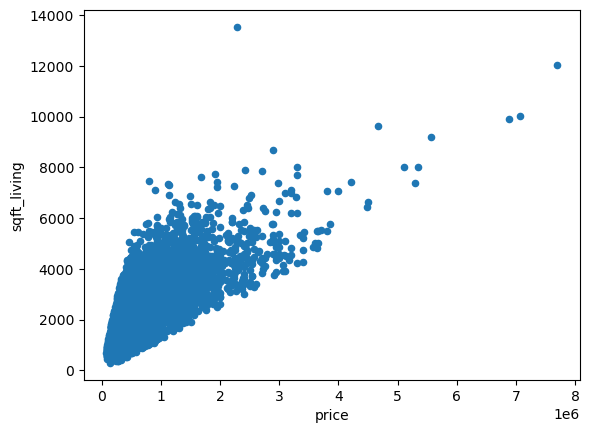

In [9]:
house_data.plot(kind = 'scatter', x = 'price', y = 'sqft_living');

Text(0.5, 1.0, 'Price vs. Sqft of living space')

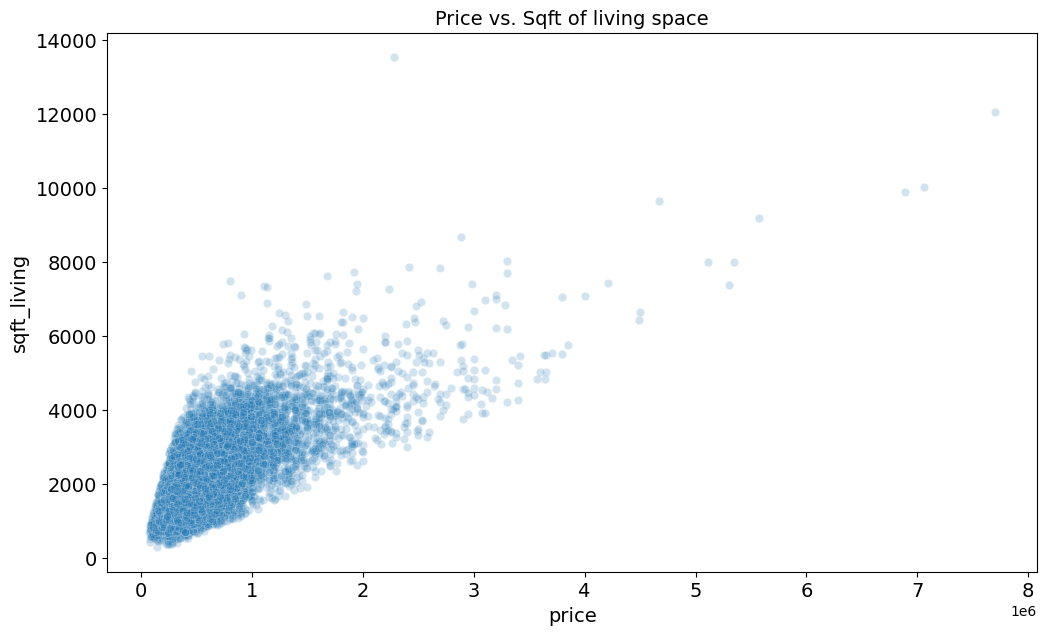

In [45]:
fontsize = 14
plt.figure(figsize = (12,7))
sns.scatterplot(data = house_data, x = 'price', y = 'sqft_living', alpha = 0.2)
plt.xticks(fontsize = fontsize)
plt.xlabel('price', fontsize = fontsize)
plt.yticks(fontsize = fontsize)
plt.ylabel('sqft_living', fontsize = fontsize)
plt.title('Price vs. Sqft of living space', fontsize = fontsize)
# house_data.plot(kind = 'scatter', x = 'price', y = 'sqft_living');

There appears to be a strong positive relationship between price and sqft of living space

### 2. In working toward building the model, I create a df, X, of the sqft_living space column and a series, y, of the target variable, price.

In [46]:
predictor_vars = ['sqft_living']

X = house_data[predictor_vars]
type(X)

pandas.core.frame.DataFrame

In [47]:
y = house_data['price']

In [48]:
X.head(2)

,sqft_living
0,1180
1,2570


In [14]:
y.head(2)

0    221900.0
1    538000.0
Name: price, dtype: float64

Inspect column titles, the 'view' column, and the types of objects created

In [15]:
house_data.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [16]:
house_data['view'].unique()

array([0, 3, 4, 2, 1])

In [17]:
type(house_data['price'])

pandas.core.series.Series

How well does the model predict on data that it has not yet seen? I set aside a portion of hte data as a test set to train the model on the remaining portion, which is one way to accomplish this. 

### 3. I use the train_test_split function to create a training and a test set from X and y. I name the resulting pieces X_train, X_test, y_train, y_test. I use 30% of the data in the test set and the random_state parameter so that I can compare model performance as I change the way I build my model. 

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42, shuffle = True)

Now to fit my model beginning with a linear regression model.

### 4. Import the LinearRegression class from the linear_model module. Then create a linear regression instance and fit it to the training data.

In [27]:
linreg = LinearRegression().fit(X_train, y_train)

In [30]:
linreg

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
linreg.score(X_train, y_train)

0.4970072727500471

In [32]:
linreg.coef_

array([279.51011741])

In [33]:
linreg.intercept_

np.float64(-41947.45401876257)

In [44]:
linreg.predict(X_test)

array([ 536638.48902466,  768631.88647686, 1011805.68862555, ...,
        279489.18100536,  556204.19724352,  659622.94068607],
      shape=(6484,))

Question 6 should say to generate a set of predictions on X_test, not y_test.